# App-29 — Équilibrage de chaîne d'assemblage (SALBP)
## De l'affectation au certificat : statut, borne, provenance

**Navigation** : [Index Applications](../README.md) | [Série Search](../../README.md) | [CSP-4 Scheduling](../../Part2-CSP/CSP-4-Scheduling.ipynb)

> **Hommage à Ilias Kalalou et Kaelan Grall — projet B1, EPITA SCIA 2026.** Leur projet ne s'est pas contenté d'écrire un modèle : il a réuni dans un même appareil **SALBP-1**, **SALBP-2**, CP-SAT, PuLP/CBC, l'heuristique historique **Ranked Positional Weight**, 25 instances, 57 tests, une application Streamlit, une variante multi-modèles et une exploration bi-objectif. Cette volonté de faire dialoguer modèle exact, formulation indépendante, heuristique de métier et interface est le geste central de cette distillation.

Une chaîne d'assemblage semble linéaire : les tâches avancent, station après station. Son optimisation ne l'est pas. Une décision locale — placer une tâche dès qu'elle tient — modifie l'espace disponible pour ses successeurs, le nombre de postes à ouvrir et la cadence industrielle atteignable. Deux solutions qui utilisent quatre stations ne racontent pas nécessairement la même histoire : l'une peut être prouvée optimale, l'autre seulement trouvée avant un timeout. Deux fichiers appelés `BUXEY` ne décrivent pas nécessairement la même instance. Une courbe stations–cycle ne devient pas un front de Pareto parce qu'on a relié ses points.

CoursIA reconstruit donc ici de petites expériences indépendantes pour répondre à une question plus exigeante que « quelle valeur le solveur affiche-t-il ? » :

1. **Que modélise-t-on ?** SALBP-1 fixe le cycle et minimise les stations ; SALBP-2 fixe les stations et minimise le cycle.
2. **Que possède-t-on ?** Une affectation candidate, que l'on peut valider sans faire confiance au modèle qui l'a produite.
3. **Que prouve-t-on ?** Un statut, un incumbent et une meilleure borne dont la combinaison ferme — ou non — l'optimalité.
4. **À quoi compare-t-on ?** Une référence dont l'identité structurelle et la provenance sont vérifiées, jamais un nom seul.
5. **Quel compromis observe-t-on ?** Un front filtré par dominance, certifié seulement si chacune de ses sous-résolutions l'est.
6. **Quel contrat industriel choisit-on ?** Protéger chaque modèle de produit séparément ou optimiser une charge moyenne pondérée par la demande.

Le notebook est entièrement offline. Il ne copie ni module, ni cellule, ni prose, ni figure du projet B1 : il en préserve l'ambition et transforme ses questions en un parcours CoursIA autonome sur les **niveaux de preuve**.

**Parcours (~70 min)** — problème industriel → validateur indépendant → deux modèles exacts → RPW → benchmark et certificats → provenance → Pareto → MMALBP → exercices → hommage et bilan critique.

## 1. Préparer l'expérience — une ligne, deux problèmes

Une ligne d'assemblage transforme un produit par une suite de tâches indivisibles. Chaque tâche $i$ possède une durée $t_i$ et certaines tâches doivent être terminées avant que d'autres puissent commencer. Ces relations forment un **graphe orienté acyclique** : l'arc $(i,j)$ signifie que $i$ ne peut pas être affectée après $j$.

La ligne est découpée en stations ordonnées $0,1,\ldots,m-1$. À une station donnée, un opérateur ou un poste exécute séquentiellement toutes les tâches qui lui sont affectées. Si la cadence impose qu'un produit quitte une station toutes les $C$ unités de temps, la charge de chaque station doit vérifier

$$\sum_i t_i x_{i,s} \le C.$$

Trois familles de contraintes apparaissent déjà :

- **partition** : chaque tâche est affectée exactement une fois ;
- **capacité** : chaque station respecte le temps de cycle ;
- **précédence** : si $(i,j)$ est un arc, alors la station de $i$ ne dépasse pas celle de $j$.

Le même système physique produit deux problèmes classiques selon la variable que l'usine considère comme fixée :

- **SALBP-1** (*Simple Assembly Line Balancing Problem type 1*) : le temps de cycle $C$ est fixé par la demande ; on minimise le nombre de stations $m$. Ajouter une station coûte de l'espace, de l'équipement et du personnel.
- **SALBP-2** : le nombre de stations $m$ est fixé par l'installation ; on minimise le cycle $C$. Réduire le cycle augmente la cadence, tant que les précédences et les charges le permettent.

Cette dualité est le fil du notebook. SALBP-1 donne le bord gauche du compromis — le moins de stations possible pour un cycle imposé. SALBP-2 explore ensuite ce que l'on gagne en cadence lorsqu'on autorise davantage de stations.

Les instances ci-dessous sont **synthétiques, déterministes et propres à CoursIA**. Elles sont volontairement petites : leur rôle n'est pas d'imiter une usine complète, mais de rendre inspectables les affectations, les bornes et les certificats. Aucun module étudiant n'est importé. Le dossier `data/app29-salbp-audit` sérialise les résultats afin qu'une affirmation du texte puisse être recroisée avec un artefact précis.

In [1]:
from __future__ import annotations

from dataclasses import asdict, dataclass
from hashlib import sha256
from pathlib import Path
import json, math, platform, time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pulp
from ortools.sat.python import cp_model
import ortools

DATA_DIR = Path("data/app29-salbp-audit")
if not DATA_DIR.exists():
    DATA_DIR = Path("MyIA.AI.Notebooks/Search/Applications/Hybrid/data/app29-salbp-audit")
DATA_DIR.mkdir(parents=True, exist_ok=True)

@dataclass(frozen=True)
class SALBPInstance:
    name: str
    durations: tuple[int, ...]
    precedences: tuple[tuple[int, int], ...]
    cycle_time: int

    @property
    def tasks(self):
        return tuple(range(len(self.durations)))

@dataclass
class SolveReport:
    method: str
    status: str
    objective: float | None
    best_bound: float | None
    gap: float | None
    wall_time: float
    assignment: dict[int, int] | None
    valid: bool

STATUS_NAMES = {
    cp_model.OPTIMAL: "OPTIMAL", cp_model.FEASIBLE: "FEASIBLE",
    cp_model.INFEASIBLE: "INFEASIBLE", cp_model.MODEL_INVALID: "MODEL_INVALID",
    cp_model.UNKNOWN: "UNKNOWN",
}

def relative_gap(objective, bound):
    if objective is None or bound is None:
        return None
    return abs(objective - bound) / max(1.0, abs(objective))

print({"python": platform.python_version(), "ortools": ortools.__version__, "pulp": pulp.__version__})


{'python': '3.13.14', 'ortools': '9.15.6755', 'pulp': '3.3.1'}


### Lire l'environnement avant de lire le résultat

Les versions ne sont pas une formalité bibliographique. OR-Tools et CBC évoluent : présolve, stratégies de branchement, parallélisme et restitution des statuts peuvent changer le temps nécessaire pour fermer une preuve sans changer le modèle mathématique. Afficher Python, OR-Tools et PuLP permet de distinguer **l'expérience reproduite ici** d'un résultat obtenu sous un autre environnement.

La structure `SolveReport` impose surtout un vocabulaire commun aux méthodes :

- `status` décrit ce que le moteur affirme à l'arrêt ;
- `objective` est la valeur de la meilleure solution réalisable trouvée — l'**incumbent** ;
- `best_bound` borne ce que pourrait encore valoir une solution meilleure ;
- `gap` mesure la distance relative entre ces deux nombres ;
- `assignment` contient la décision concrète tâche → station ;
- `valid` rapporte le verdict d'un contrôle indépendant.

Ces champs empêchent une confusion fréquente. Une affectation peut être valide sans être optimale ; une valeur peut être optimale pour un modèle mal encodé ; une borne peut être forte sans qu'aucune solution n'ait encore été trouvée. Le niveau de confiance vient de la **conjonction** des preuves, pas d'une seule étiquette.

Dans ce notebook, l'égalité `objective == best_bound` accompagnée du statut `OPTIMAL` ferme la preuve du solveur. Elle ne dispense jamais de valider l'affectation : le solveur certifie le modèle qu'on lui a donné, pas l'intention que l'auteur avait en tête.

## 2. Valider hors du solveur — l'optimalité du mauvais modèle reste mauvaise

Un solveur exact répond avec rigueur à la question qu'on lui pose. Il ne sait pas si une contrainte métier a été omise, si une unité a été mal convertie ou si l'objectif imprimé correspond à celui qui a réellement été minimisé. Un modèle peut donc retourner `OPTIMAL` tout en décrivant incorrectement la ligne d'assemblage.

Le validateur suivant adopte une autre perspective. Il ne consulte ni `BoolVar`, ni contraintes internes, ni valeur d'objectif mémorisée par le solveur. À partir de la seule affectation sérialisée, il recalcule :

1. **la couverture** — chaque tâche attendue apparaît exactement une fois ;
2. **le domaine** — chaque station est un indice entier non négatif ;
3. **les précédences** — aucun arc $(i,j)$ ne place $i$ après $j$ ;
4. **les charges** — la somme des durées par station respecte le cycle annoncé ;
5. **les grandeurs dérivées** — nombre de stations utilisées et charge maximale réelle.

Cette séparation crée deux lignes de défense indépendantes. Le solveur établit une propriété du modèle ; le validateur établit une propriété de l'artefact livré. Si elles divergent, on ne moyenne pas les verdicts : on arrête l'interprétation et on cherche quelle hypothèse diffère.

Le même principe s'applique aux benchmarks. Avant de comparer un résultat à une meilleure valeur connue, `identity_key` construit une empreinte de l'instance complète. La provenance devient ainsi une contrainte vérifiable du protocole, au même titre que la capacité d'une station.

In [2]:
def validate_solution(instance, assignment, cycle_time=None, expected_stations=None):
    if assignment is None or set(assignment) != set(instance.tasks):
        return False, {"reason": "task_coverage"}
    if any(not isinstance(s, int) or s < 0 for s in assignment.values()):
        return False, {"reason": "station_index"}
    for i, j in instance.precedences:
        if assignment[i] > assignment[j]:
            return False, {"reason": "precedence", "edge": [i, j]}
    loads = {}
    for task, station in assignment.items():
        loads[station] = loads.get(station, 0) + instance.durations[task]
    limit = instance.cycle_time if cycle_time is None else cycle_time
    if max(loads.values(), default=0) > limit:
        return False, {"reason": "cycle", "loads": loads, "limit": limit}
    stations = max(assignment.values(), default=-1) + 1
    if expected_stations is not None and stations > expected_stations:
        return False, {"reason": "station_count", "stations": stations}
    return True, {"loads": loads, "stations": stations, "cycle": max(loads.values())}

def identity_key(instance):
    payload = {
        "n_tasks": len(instance.durations),
        "durations": list(instance.durations),
        "precedences": [list(e) for e in sorted(instance.precedences)],
        "cycle_time": instance.cycle_time,
    }
    raw = json.dumps(payload, sort_keys=True, separators=(",", ":"))
    return sha256(raw.encode()).hexdigest()

def lower_bounds(instance):
    load = math.ceil(sum(instance.durations) / instance.cycle_time)
    longest = max(instance.durations)
    return {"load_lb": load, "single_task_feasible": longest <= instance.cycle_time}

TOY = SALBPInstance("coursia-toy", (6, 4, 5, 3, 7, 4, 6, 5),
                    ((0,2),(0,3),(1,3),(2,4),(3,5),(4,6),(5,6),(6,7)), 14)
print(identity_key(TOY)[:16], lower_bounds(TOY))


11480c70a3adf3d4 {'load_lb': 3, 'single_task_feasible': True}


### Avant le solveur : deux contrôles qui ne prouvent pas la même chose

La borne de charge vaut

$$LB_{charge}=\left\lceil\frac{\sum_i t_i}{C}\right\rceil.$$

Elle vient d'un argument de conservation : si une station peut absorber au plus $C$ unités de travail, $m$ stations ne peuvent en absorber plus de $mC$. Avec 40 unités de durée et un cycle 14, trois stations offrent 42 unités de capacité totale ; moins de trois est impossible. Cet argument reste vrai quelles que soient les précédences : c'est pourquoi la borne est **sûre**.

Mais elle peut être faible. Les précédences fragmentent parfois cette capacité théorique : deux tâches qui « tiendraient » arithmétiquement ensemble peuvent devoir être séparées parce que leurs successeurs et prédécesseurs occupent déjà les positions voisines. La borne dit donc « impossible en dessous », jamais « réalisable à ce niveau ». Une solution à la valeur de la borne ferme l'optimum ; la borne seule ne le fait pas.

Le contrôle `single_task_feasible` répond à une question encore plus élémentaire : une tâche isolée dépasse-t-elle le cycle ? Si oui, aucune affectation n'est possible dans le modèle SALBP simple — il faut scinder la tâche, augmenter le cycle ou changer le procédé. Ce test n'est pas une optimisation ; c'est un diagnostic de cohérence des données.

Enfin, le hash affiché n'est pas un identifiant décoratif. Il encode le nombre de tâches, toutes les durées, tous les arcs triés et le cycle. Changer une seule durée transforme l'expérience et doit transformer son identité. Nous utiliserons cette propriété en section 6 pour empêcher qu'une proximité de nom se transforme abusivement en comparaison scientifique.

## 3. SALBP-1 et SALBP-2 avec CP-SAT — le même atelier vu des deux côtés

Pour SALBP-1, nous créons une variable booléenne $x_{i,s}$ qui vaut 1 lorsque la tâche $i$ est affectée à la station $s$. `AddExactlyOne` impose la partition. La variable entière

$$station_i=\sum_s s\,x_{i,s}$$

n'ajoute aucune décision : elle donne une forme lisible aux précédences, `station[i] <= station[j]`. Chaque station reçoit aussi un booléen `used[s]`; l'objectif minimise leur somme. La contrainte `used[s] >= used[s+1]` casse une symétrie évidente : si quatre stations sont utilisées, on les numérote 0–3 plutôt que de laisser des trous arbitraires.

SALBP-2 garde la partition et les précédences, mais remplace le cycle constant par une variable entière. Pour un nombre de stations fixé, chaque charge est bornée par cette variable et l'objectif la minimise. On ne « convertit » donc pas simplement le résultat SALBP-1 : on résout une question différente sur le même graphe.

Les paramètres de recherche sont volontairement sobres : un worker et une graine fixe. Sur ces petites instances, cela favorise la reproductibilité des traces et suffit à fermer les preuves. Sur un cas industriel, plusieurs workers et une limite de temps seraient raisonnables, mais un incumbent `FEASIBLE` varierait alors potentiellement d'un run à l'autre ; il faudrait rapporter cette dispersion au lieu de choisir le meilleur essai silencieusement.

La cellule suivante résout les deux problèmes sur `TOY`, puis passe l'affectation SALBP-1 au validateur indépendant. Lisez simultanément **la valeur**, **la borne**, **le statut** et **les charges** : aucun de ces éléments ne remplace les autres.

In [3]:
def solve_salbp1_cpsat(instance, time_limit=10.0):
    n = len(instance.tasks)
    model = cp_model.CpModel()
    x = {(i,s): model.new_bool_var(f"x_{i}_{s}") for i in instance.tasks for s in range(n)}
    used = [model.new_bool_var(f"used_{s}") for s in range(n)]
    station = {i: model.new_int_var(0, n-1, f"station_{i}") for i in instance.tasks}
    for i in instance.tasks:
        model.add_exactly_one(x[i,s] for s in range(n))
        model.add(station[i] == sum(s*x[i,s] for s in range(n)))
    for s in range(n):
        count = sum(x[i,s] for i in instance.tasks)
        model.add(count >= used[s])
        model.add(count <= n*used[s])
        model.add(sum(instance.durations[i]*x[i,s] for i in instance.tasks) <= instance.cycle_time)
        if s+1 < n: model.add(used[s] >= used[s+1])
    for i,j in instance.precedences: model.add(station[i] <= station[j])
    model.minimize(sum(used))
    solver = cp_model.CpSolver(); solver.parameters.max_time_in_seconds = time_limit
    solver.parameters.num_search_workers = 1; solver.parameters.random_seed = 29
    t0=time.perf_counter(); status=solver.solve(model); wall=time.perf_counter()-t0
    name=STATUS_NAMES.get(status, "UNKNOWN")
    assignment = {i: int(solver.value(station[i])) for i in instance.tasks} if status in (cp_model.OPTIMAL,cp_model.FEASIBLE) else None
    obj=float(solver.objective_value) if assignment else None
    bound=float(solver.best_objective_bound) if assignment else None
    valid=validate_solution(instance, assignment)[0] if assignment else False
    return SolveReport("CP-SAT SALBP-1", name, obj, bound, relative_gap(obj,bound), wall, assignment, valid)

def solve_salbp2_cpsat(instance, n_stations, time_limit=10.0):
    model=cp_model.CpModel(); n=len(instance.tasks)
    x={(i,s): model.new_bool_var(f"x_{i}_{s}") for i in instance.tasks for s in range(n_stations)}
    station={i:model.new_int_var(0,n_stations-1,f"station_{i}") for i in instance.tasks}
    cycle=model.new_int_var(max(instance.durations),sum(instance.durations),"cycle")
    for i in instance.tasks:
        model.add_exactly_one(x[i,s] for s in range(n_stations))
        model.add(station[i] == sum(s*x[i,s] for s in range(n_stations)))
    for s in range(n_stations):
        model.add(sum(instance.durations[i]*x[i,s] for i in instance.tasks) <= cycle)
    for i,j in instance.precedences: model.add(station[i] <= station[j])
    model.minimize(cycle)
    solver=cp_model.CpSolver(); solver.parameters.max_time_in_seconds=time_limit
    solver.parameters.num_search_workers=1; solver.parameters.random_seed=29
    t0=time.perf_counter(); status=solver.solve(model); wall=time.perf_counter()-t0
    name=STATUS_NAMES.get(status,"UNKNOWN")
    assignment={i:int(solver.value(station[i])) for i in instance.tasks} if status in (cp_model.OPTIMAL,cp_model.FEASIBLE) else None
    obj=float(solver.objective_value) if assignment else None; bound=float(solver.best_objective_bound) if assignment else None
    valid=validate_solution(instance,assignment,cycle_time=math.ceil(obj),expected_stations=n_stations)[0] if assignment else False
    return SolveReport("CP-SAT SALBP-2",name,obj,bound,relative_gap(obj,bound),wall,assignment,valid)

cp1=solve_salbp1_cpsat(TOY)
cp2=solve_salbp2_cpsat(TOY, int(cp1.objective))
print(pd.DataFrame([{k:v for k,v in asdict(r).items() if k != "assignment"} for r in [cp1,cp2]]).to_string(index=False))
print(validate_solution(TOY, cp1.assignment))


        method  status  objective  best_bound  gap  wall_time  valid
CP-SAT SALBP-1 OPTIMAL        4.0         4.0  0.0   0.040857   True
CP-SAT SALBP-2 OPTIMAL       11.0        11.0  0.0   0.014211   True
(True, {'loads': {1: 14, 0: 4, 2: 11, 3: 11}, 'stations': 4, 'cycle': 14})


### Deux optima, deux informations

SALBP-1 retourne quatre stations pour le cycle imposé 14. La borne vaut également 4 et le statut est `OPTIMAL` : aucune affectation à trois stations ne respecte simultanément capacité et précédences dans le modèle. Le validateur recalcule quatre stations et des charges 4, 14, 11 et 11 ; aucune ne dépasse 14. La valeur du solveur et l'objet livré racontent donc la même histoire.

SALBP-2 repart de quatre stations mais libère le cycle. Il ferme l'optimum à 11. Ce résultat révèle l'espace perdu par le cycle initial : avec la même installation à quatre postes, le graphe permettrait une cadence de 11 unités, soit trois unités plus rapide. Ce n'est pas une recommandation industrielle automatique — réduire le cycle peut demander des ressources, une synchronisation ou des marges absentes du modèle — mais c'est une propriété exacte de cette instance.

Le couple de résultats illustre déjà le futur front de Pareto : $(4,14)$ est réalisable lorsque 14 est imposé, mais $(4,11)$ domine cette organisation si le cycle devient une variable de décision. À l'inverse, descendre sous quatre stations est impossible pour ce modèle, même avec le cycle 14.

Si le solveur avait arrêté SALBP-2 avec `FEASIBLE`, la valeur 11 aurait décrit une cadence réalisable et validée, tandis que la borne aurait indiqué jusqu'où une amélioration restait possible. Le notebook aurait alors parlé de **meilleure solution observée**, jamais d'optimum. La précision du vocabulaire suit le certificat, pas l'enthousiasme suscité par le chiffre.

## 4. Deuxième formulation exacte et baseline RPW — trianguler plutôt que croire

Le projet B1 avait une intuition pédagogique forte : confronter **deux formulations exactes** à une **heuristique de domaine**. Cette triangulation répond à trois besoins différents.

**CP-SAT** encode naturellement les choix discrets et les implications. **PuLP/CBC** reconstruit le même problème comme programme linéaire en nombres entiers : variables binaires, sommes de capacité, précédences exprimées par les indices pondérés. Si les deux moteurs ferment le même optimum et si leurs affectations passent un validateur écrit hors des deux modèles, une erreur propre à une API devient moins probable. Cette concordance n'est pas une preuve formelle d'équivalence des programmes, mais c'est un contrôle expérimental puissant.

**Ranked Positional Weight (RPW)** ne cherche pas de certificat. Pour chaque tâche, son poids additionne sa propre durée et celles de tous ses descendants. Une tâche longue située en amont reçoit donc une priorité élevée, car la retarder menace une grande partie du graphe. L'algorithme ouvre les stations dans l'ordre et choisit parmi les tâches éligibles celle de poids maximal qui tient encore dans la capacité.

RPW apporte ce que les exacts n'apportent pas directement :

- une solution constructive rapide ;
- une borne supérieure sur le nombre de stations ;
- une explication de métier — « traiter d'abord ce qui pèse sur beaucoup de successeurs » ;
- éventuellement un point de départ (*hint*) pour une recherche exacte plus grande.

Son coût est l'absence de borne duale. Même lorsqu'il égale l'optimum connu, RPW n'a pas démontré qu'une meilleure organisation était impossible. La cellule suivante conserve donc le statut `HEURISTIC` au lieu de le déduire de la valeur obtenue.

In [4]:
def solve_salbp1_pulp(instance, time_limit=10.0):
    n=len(instance.tasks); prob=pulp.LpProblem("SALBP1",pulp.LpMinimize)
    x=pulp.LpVariable.dicts("x",(instance.tasks,range(n)),cat="Binary")
    used=pulp.LpVariable.dicts("used",range(n),cat="Binary")
    for i in instance.tasks: prob += pulp.lpSum(x[i][s] for s in range(n)) == 1
    for s in range(n):
        prob += pulp.lpSum(instance.durations[i]*x[i][s] for i in instance.tasks) <= instance.cycle_time
        for i in instance.tasks: prob += x[i][s] <= used[s]
        if s+1<n: prob += used[s] >= used[s+1]
    for i,j in instance.precedences:
        prob += pulp.lpSum(s*x[i][s] for s in range(n)) <= pulp.lpSum(s*x[j][s] for s in range(n))
    prob += pulp.lpSum(used[s] for s in range(n))
    t0=time.perf_counter(); prob.solve(pulp.PULP_CBC_CMD(msg=False,timeLimit=time_limit,threads=1)); wall=time.perf_counter()-t0
    raw=pulp.LpStatus[prob.status]; status={"Optimal":"OPTIMAL","Infeasible":"INFEASIBLE","Not Solved":"UNKNOWN"}.get(raw,raw.upper())
    assignment=None
    if status in ("OPTIMAL","FEASIBLE"):
        assignment={i:max(range(n),key=lambda s:pulp.value(x[i][s]) or 0) for i in instance.tasks}
    obj=float(pulp.value(prob.objective)) if assignment else None
    valid=validate_solution(instance,assignment)[0] if assignment else False
    return SolveReport("PuLP/CBC SALBP-1",status,obj,obj if status=="OPTIMAL" else None,0.0 if status=="OPTIMAL" else None,wall,assignment,valid)

def descendants(instance, root):
    succ={i:set() for i in instance.tasks}
    for a,b in instance.precedences: succ[a].add(b)
    seen=set(); stack=list(succ[root])
    while stack:
        u=stack.pop()
        if u not in seen: seen.add(u); stack.extend(succ[u])
    return seen

def rpw_weights(instance):
    return {i:instance.durations[i]+sum(instance.durations[j] for j in descendants(instance,i)) for i in instance.tasks}

def solve_rpw(instance):
    pred={i:set() for i in instance.tasks}
    for a,b in instance.precedences: pred[b].add(a)
    weights=rpw_weights(instance); remaining=set(instance.tasks); assignment={}; station=0; load=0
    while remaining:
        eligible=[i for i in remaining if pred[i] <= set(assignment)]
        fit=[i for i in eligible if load+instance.durations[i] <= instance.cycle_time]
        if not fit: station += 1; load=0; continue
        i=max(fit,key=lambda t:(weights[t],instance.durations[t],-t))
        assignment[i]=station; load += instance.durations[i]; remaining.remove(i)
    valid,details=validate_solution(instance,assignment)
    return SolveReport("RPW", "HEURISTIC", float(details["stations"]), None, None, 0.0, assignment, valid)

pulp1=solve_salbp1_pulp(TOY); rpw1=solve_rpw(TOY)
comparison=pd.DataFrame([{k:v for k,v in asdict(r).items() if k!="assignment"} for r in [cp1,pulp1,rpw1]])
print(comparison.to_string(index=False))


          method    status  objective  best_bound  gap  wall_time  valid
  CP-SAT SALBP-1   OPTIMAL        4.0         4.0  0.0   0.040857   True
PuLP/CBC SALBP-1   OPTIMAL        4.0         4.0  0.0   0.662470   True
             RPW HEURISTIC        4.0         NaN  NaN   0.000000   True


### Même valeur, trois statuts épistémiques

Les trois méthodes retournent quatre stations et les trois affectations sont valides. Pourtant, le tableau ne contient pas trois preuves équivalentes.

- **CP-SAT** annonce `OPTIMAL`, incumbent 4, borne 4 : son arbre de recherche est fermé pour le modèle CP-SAT.
- **CBC** annonce également `OPTIMAL` et 4 : une seconde formulation mathématique ferme indépendamment la même valeur.
- **RPW** construit 4 sans borne : il montre que quatre stations suffisent, pas que trois sont impossibles.

Pourquoi garder RPW si les solveurs exacts sont rapides ? Parce que ce petit cas est un laboratoire. Lorsque la taille augmente, un exact peut manquer de temps, tandis qu'une heuristique continue de fournir une organisation exploitable. Le bon protocole ne choisit pas entre « exact » et « heuristique » comme entre deux camps : il utilise RPW pour produire rapidement un incumbent et les solveurs pour mesurer ou fermer ce qui reste inconnu.

La concordance observée autorise une phrase précise : **RPW atteint ici la valeur optimale certifiée par deux solveurs exacts**. Elle n'autorise pas « RPW est optimal » comme propriété générale. Sur une autre instance ou avec un autre tie-break, l'heuristique peut ouvrir davantage de stations. C'est la différence entre décrire un run et attribuer une garantie à un algorithme.

Cette discipline sera conservée dans le benchmark : `HEURISTIC` restera visible même lorsque la colonne `objective` coïncide avec les lignes exactes.

## 5. Benchmark déterministe — un tableau n'est pas encore une expérience

Une comparaison de solveurs devient interprétable lorsque les entrées, paramètres et verdicts sont reliés. Nous générons quatre DAG par couches avec des graines fixes et leur ajoutons l'instance fil rouge. Pour chaque instance, CP-SAT, CBC et RPW reçoivent exactement les mêmes durées, précédences et cycle — donc le même hash structurel.

Le générateur ne vise pas le réalisme industriel. Son rôle est de produire un petit panel où l'on peut :

- répéter l'expérience sans réseau ni fichier externe ;
- inspecter les arcs et les durées sérialisés dans `provenance.json` ;
- croiser les deux formulations exactes ;
- vérifier chaque affectation hors solveur ;
- observer la différence entre une valeur, une borne et un statut.

Le temps mural est enregistré, mais il ne faut pas en faire un classement de performance. Cinq petites instances, un seul environnement et des durées de quelques centièmes de seconde ne suffisent pas pour conclure que CP-SAT « bat » CBC ou inversement : démarrage du processus CBC, présolve et bruit système peuvent dominer. Le benchmark teste ici la **cohérence des preuves**, pas la scalabilité.

Chaque ligne est écrite dans `benchmark_runs.csv`. Ce fichier n'est pas une copie décorative de l'affichage : il constitue l'artefact stable que la PR, le registre et un futur rerun peuvent recroiser.

In [5]:
def generated_instance(seed, n=14, cycle=18):
    rng=np.random.default_rng(seed); durations=tuple(int(x) for x in rng.integers(2,9,size=n))
    layer=np.array_split(np.arange(n),4); edges=[]
    for a,b in zip(layer[:-1],layer[1:]):
        for j in b:
            candidates=[int(i) for i in a if rng.random()<0.55]
            if not candidates: candidates=[int(rng.choice(a))]
            edges.extend((i,int(j)) for i in candidates)
    return SALBPInstance(f"generated-{seed}",durations,tuple(sorted(set(edges))),cycle)

instances=[TOY]+[generated_instance(s) for s in (11,29,47,71)]
rows=[]
for inst in instances:
    for report in (solve_salbp1_cpsat(inst),solve_salbp1_pulp(inst),solve_rpw(inst)):
        rows.append({"instance":inst.name,"identity":identity_key(inst),**{k:v for k,v in asdict(report).items() if k!="assignment"}})
bench=pd.DataFrame(rows)
bench.to_csv(DATA_DIR/"benchmark_runs.csv",index=False)
print(bench[["instance","method","status","objective","best_bound","gap","valid"]].to_string(index=False))


    instance           method    status  objective  best_bound  gap  valid
 coursia-toy   CP-SAT SALBP-1   OPTIMAL        4.0         4.0  0.0   True
 coursia-toy PuLP/CBC SALBP-1   OPTIMAL        4.0         4.0  0.0   True
 coursia-toy              RPW HEURISTIC        4.0         NaN  NaN   True
generated-11   CP-SAT SALBP-1   OPTIMAL        4.0         4.0  0.0   True
generated-11 PuLP/CBC SALBP-1   OPTIMAL        4.0         4.0  0.0   True
generated-11              RPW HEURISTIC        4.0         NaN  NaN   True
generated-29   CP-SAT SALBP-1   OPTIMAL        4.0         4.0  0.0   True
generated-29 PuLP/CBC SALBP-1   OPTIMAL        4.0         4.0  0.0   True
generated-29              RPW HEURISTIC        4.0         NaN  NaN   True
generated-47   CP-SAT SALBP-1   OPTIMAL        4.0         4.0  0.0   True
generated-47 PuLP/CBC SALBP-1   OPTIMAL        4.0         4.0  0.0   True
generated-47              RPW HEURISTIC        4.0         NaN  NaN   True
generated-71   CP-SAT SAL

### Ce que ferme le tableau — et ce qu'il laisse ouvert

Les dix lignes exactes rapportent `OPTIMAL`, une borne égale à l'incumbent et `valid=True`. Sur ce panel précis, CP-SAT et CBC concordent donc sur cinq valeurs fermées, et leurs solutions satisfont un contrôle indépendant. RPW retourne cinq affectations valides et atteint aussi quatre stations à chaque fois.

Cette régularité est utile mais elle révèle une limite du banc : les instances sont faciles et peu discriminantes pour la qualité de RPW. On ne doit pas convertir « 5/5 égalités » en taux de succès général. Pour étudier l'heuristique, il faudrait des familles plus grandes et diverses, des répétitions, des tie-breaks alternatifs et des écarts à une borne ou à un optimum certifié.

Le tableau remplit néanmoins son objectif de lecture :

- `objective=4`, `best_bound=4`, `gap=0`, `OPTIMAL` signifie **preuve fermée** pour l'exact ;
- `objective=4`, borne absente, `HEURISTIC` signifie **solution constructive** pour RPW ;
- `valid=True` signifie seulement que l'affectation respecte les contraintes recalculées ;
- les temps sont des observations locales, pas une loi de performance.

Si une future instance se terminait en `FEASIBLE` avec incumbent 5 et borne 4, le gap quantifierait une zone d'incertitude : quatre stations restent possibles selon la borne, cinq sont réalisables selon l'incumbent. Le résultat pédagogiquement honnête serait « une solution valide à cinq, optimum entre quatre et cinq », pas « optimum cinq » ni « échec du solveur ».

C'est cette lecture — davantage que la valeur uniforme 4 — qui constitue le résultat du benchmark.

## 6. Une référence doit identifier l'instance — le nom n'est pas une preuve

Les bibliothèques de SALBP circulent sous des noms historiques, parfois converties entre formats, cycles ou conventions d'indexation. Un fichier local peut conserver le nom d'une famille alors qu'une durée, un arc ou le temps de cycle a changé. Comparer sa solution à une table externe par simple égalité de chaîne crée alors un nombre très précis — mais dépourvu de sens.

Une **BKS** (*best known solution*) n'est pas seulement une valeur. C'est le triplet :

1. une instance précisément identifiée ;
2. une valeur associée à cette instance et à une variante du problème ;
3. une source et, idéalement, une date ou une version.

Le contrat `join_bks` matérialise le premier point. La clé SHA-256 est calculée sur les données structurelles qui définissent ici l'expérience : nombre de tâches, durées, arcs triés et cycle. Le nom reste un libellé humain ; il n'entre pas comme preuve de comparabilité.

La démonstration construit volontairement deux références appelées `coursia-toy`. La première porte l'identité exacte de `TOY`. La seconde est issue d'une instance homonyme dont une durée diffère. Une jointure naïve accepterait les deux ; notre contrat doit refuser la seconde et, surtout, **ne calculer aucun gap** à sa valeur 2.

In [6]:
def join_bks(instance, reference):
    actual=identity_key(instance)
    if reference.get("identity") != actual:
        return {"status":"not_comparable","reason":"structural_identity_mismatch","reference":reference.get("value")}
    return {"status":"comparable","reference":reference["value"],"identity":actual}

accepted={"name":"coursia-toy","identity":identity_key(TOY),"value":int(cp1.objective)}
altered=SALBPInstance("coursia-toy",tuple(list(TOY.durations[:-1])+[6]),TOY.precedences,TOY.cycle_time)
refused={"name":"coursia-toy","identity":identity_key(altered),"value":2}
provenance={
    "generated_on":"2026-09-01","environment":{"python":platform.python_version(),"ortools":ortools.__version__,"pulp":pulp.__version__},
    "instances":[{"name":i.name,"identity":identity_key(i),"n_tasks":len(i.tasks),"durations":list(i.durations),"precedences":[list(e) for e in i.precedences],"cycle_time":i.cycle_time} for i in instances],
    "joins":{"accepted":join_bks(TOY,accepted),"refused":join_bks(TOY,refused)}
}
(DATA_DIR/"provenance.json").write_text(json.dumps(provenance,indent=2,ensure_ascii=False),encoding="utf-8")
print(json.dumps(provenance["joins"],indent=2,ensure_ascii=False))


{
  "accepted": {
    "status": "comparable",
    "reference": 4,
    "identity": "11480c70a3adf3d41ff8ab37bcda3860bf8bc8bf318cf841a508f5254035b972"
  },
  "refused": {
    "status": "not_comparable",
    "reason": "structural_identity_mismatch",
    "reference": 2
  }
}


### Le refus est le résultat scientifique

La jointure acceptée restitue la valeur 4 parce que l'empreinte de la référence correspond exactement à celle de `TOY`. La jointure refusée porte le même nom visible et propose une valeur spectaculaire de 2, mais son hash diffère : `structural_identity_mismatch` arrête la comparaison.

Ce verdict négatif n'est pas une absence de résultat. Il établit qu'avec les métadonnées présentes, on **ne sait pas** relier honnêtement la valeur externe à l'instance résolue. Calculer `(4-2)/2 = 100 %` produirait un « gap » arithmétiquement correct et scientifiquement faux, puisqu'il comparerait deux problèmes différents.

Le coût de ce contrat est opérationnel : il faut archiver les données structurelles, leur origine, leur licence et leur checksum. Le bénéfice est durable : un changement de parseur, de cycle ou de fichier devient détectable ; une table historique peut être rejointe ou refusée automatiquement ; un lecteur sait quelle partie du résultat est reproduite et quelle partie reste non comparable.

Dans une étude externe complète, l'identité ne suffirait pas encore. Il faudrait conserver la citation de la BKS, la variante exacte de SALBP, et vérifier que la valeur signifie bien « nombre minimal de stations au cycle C ». Ici, la petite démonstration isole volontairement le mécanisme le plus souvent oublié : **avant de calculer un écart, prouver que les deux côtés désignent le même objet**.

## 7. Front stations–cycle par ε-contrainte — une courbe n'est pas un certificat

SALBP porte deux objectifs naturellement antagonistes : réduire le nombre de stations et réduire le temps de cycle. Les additionner avec un coefficient arbitraire ne révèle qu'un compromis dépendant de cette échelle. La méthode **ε-contrainte** garde un objectif — ici le cycle — et fixe successivement l'autre — le nombre de stations.

Le protocole suit quatre étapes :

1. résoudre SALBP-1 pour prouver le minimum de stations au cycle de référence ;
2. choisir une borne supérieure constructive sur les stations — RPW lorsqu'elle laisse un intervalle, sinon la borne sûre « une tâche par station » pour cette démonstration ;
3. résoudre SALBP-2 pour chaque budget entier $m$ de l'intervalle ;
4. conserver un point $(m,C)$ seulement si son cycle améliore strictement le meilleur cycle obtenu avec moins de stations.

La quatrième étape est essentielle. Si $(4,14)$ et $(5,14)$ sont réalisables, le second point consomme une station supplémentaire sans gain de cadence : il est **dominé**. Une fonction qui conserve tous les budgets dessine un escalier, mais pas nécessairement une frontière de Pareto.

Le mot `certified` impose une condition plus forte encore : SALBP-1 doit être `OPTIMAL`, et chaque résolution SALBP-2 du balayage doit être `OPTIMAL` et indépendamment valide. Si un budget termine `FEASIBLE`, les points restent des compromis observés sous limite de temps ; ils ne forment pas une frontière complète, car un point meilleur peut encore exister derrière la borne.

certified= True range= [4, 10]
 stations  objective  status  best_bound  valid
        4       13.0 OPTIMAL        13.0   True
        5       11.0 OPTIMAL        11.0   True
        6        9.0 OPTIMAL         9.0   True
        7        8.0 OPTIMAL         8.0   True


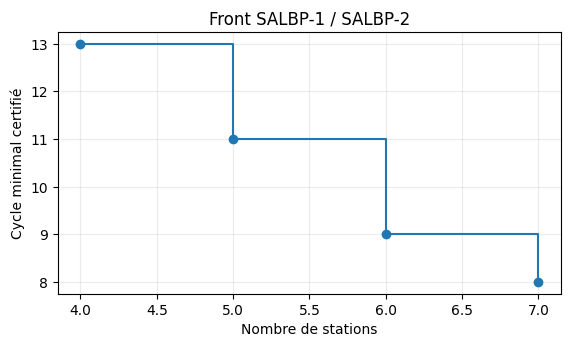

In [7]:
def strict_nondominated(reports):
    kept=[]; best_cycle=math.inf
    for stations,report in sorted(reports,key=lambda z:z[0]):
        if report.objective is not None and report.objective < best_cycle:
            kept.append((stations,report)); best_cycle=report.objective
    return kept

def pareto_front_complete(instance):
    salbp1=solve_salbp1_cpsat(instance); upper=int(solve_rpw(instance).objective)
    if salbp1.status!="OPTIMAL": return {"certified":False,"reason":"salbp1_not_optimal","points":[]}
    lower=int(salbp1.objective); upper=max(lower,upper)
    raw=[(m,solve_salbp2_cpsat(instance,m)) for m in range(lower,upper+1)]
    kept=strict_nondominated(raw)
    certified=all(r.status=="OPTIMAL" and r.valid for _,r in raw)
    return {"certified":certified,"range":[lower,upper],"points":[{"stations":m,**{k:v for k,v in asdict(r).items() if k!="assignment"}} for m,r in kept],"raw_status":[{"stations":m,"status":r.status,"valid":r.valid} for m,r in raw]}

# Une instance dédiée dont la borne RPW laisse plusieurs budgets de stations à auditer.
PARETO=SALBPInstance("pareto-line",(8,7,6,5,5,4,4,3,3,2),((0,3),(0,4),(1,4),(1,5),(2,5),(3,6),(4,6),(4,7),(5,7),(6,8),(7,8),(8,9)),14)
front=pareto_front_complete(PARETO)
# Si RPW est déjà optimal en stations, le nombre de tâches est une borne constructive triviale et sûre.
if front["range"][0]==front["range"][1]:
    raw=[(m,solve_salbp2_cpsat(PARETO,m)) for m in range(front["range"][0],len(PARETO.tasks)+1)]
    kept=strict_nondominated(raw)
    front={"certified":all(r.status=="OPTIMAL" and r.valid for _,r in raw),"range":[front["range"][0],len(PARETO.tasks)],"upper_bound":"one-task-per-station","points":[{"stations":m,**{k:v for k,v in asdict(r).items() if k!="assignment"}} for m,r in kept],"raw_status":[{"stations":m,"status":r.status,"valid":r.valid} for m,r in raw]}
(DATA_DIR/"pareto_fronts.json").write_text(json.dumps({"instance":PARETO.name,**front},indent=2),encoding="utf-8")
front_df=pd.DataFrame(front["points"])
print("certified=",front["certified"],"range=",front["range"])
print(front_df[["stations","objective","status","best_bound","valid"]].to_string(index=False))
plt.figure(figsize=(6.5,3.4)); plt.step(front_df.stations,front_df.objective,where="post",marker="o")
plt.xlabel("Nombre de stations"); plt.ylabel("Cycle minimal certifié"); plt.title("Front SALBP-1 / SALBP-2"); plt.grid(alpha=.25); plt.show()


### Lire le front : le prix marginal d'une station

Le balayage `m=4..10` est entièrement fermé : chaque sous-problème est `OPTIMAL` et valide. Après filtrage, quatre points subsistent : $(4,13)$, $(5,11)$, $(6,9)$ et $(7,8)$. Les budgets 8, 9 et 10 ne réduisent plus le cycle : ils sont réalisables, mais dominés par sept stations au même niveau de cadence.

Le front permet une lecture marginale :

- passer de 4 à 5 stations gagne 2 unités de cycle ;
- passer de 5 à 6 en gagne encore 2 ;
- passer de 6 à 7 n'en gagne plus qu'une ;
- au-delà de 7, le modèle ne trouve aucun gain possible — et le certificat affirme qu'il n'en existe pas pour cette instance.

Cette décroissance du rendement n'est pas une loi universelle ; elle dépend des durées et du graphe. Mais elle transforme la discussion industrielle. La question n'est plus « quel est le meilleur point ? » sans unité commune, mais « combien coûte une station supplémentaire, et quelle cadence certifiée achète-t-elle ? » Le décideur apporte ensuite les coûts, les marges et les contraintes non modélisées.

La forme en escalier rappelle aussi la discrétisation du problème : stations et durées sont entières. Relier les points aide la lecture, mais aucune solution fractionnaire n'existe entre eux. Enfin, `certified=True` ne vient ni de la beauté de la figure ni de sa monotonie ; il résume les sept statuts et les sept validations enregistrés dans `pareto_fronts.json`.

## 8. MMALBP — protéger chaque modèle ou optimiser le mix de demande ?

Une même ligne peut assembler plusieurs variantes d'un produit. La tâche « monter le module » dure 7 unités sur le modèle A et 3 sur le modèle B ; une autre tâche inverse ce rapport. Le **Multi-Model Assembly Line Balancing Problem** cherche une affectation commune compatible avec cette diversité.

Deux contrats industriels, souvent confondus, sont possibles.

### Contrat conservateur : capacité séparée par modèle

Pour chaque station $s$ et chaque modèle $k$, on impose

$$\sum_i t_{i,k}x_{i,s}\le C.$$

L'affectation est commune, mais chaque vecteur de durées est contrôlé séparément. Cette formulation garantit qu'un exemplaire A ou B isolé respecte le cycle. Elle ne remplace pas les durées par leur maximum tâche par tâche — combinaison qui pourrait fabriquer un « produit chimère » jamais assemblé — ; elle conserve bien une contrainte complète par modèle.

### Contrat pondéré : charge moyenne sous un mix

Si 75 % des produits sont A et 25 % B, on construit une durée moyenne par tâche,

$$\bar t_i=0{,}75\,t_{i,A}+0{,}25\,t_{i,B},$$

puis on résout un SALBP sur ces charges agrégées. Ce contrat protège le débit **moyen** du mix annoncé. Une séquence défavorable de modèles lourds peut dépasser localement le cycle : la robustesse individuelle a été échangée contre une meilleure utilisation moyenne.

Aucun contrat n'est universellement « meilleur ». Le conservateur convient lorsque le cycle doit tenir produit par produit ; le pondéré peut être pertinent avec buffers, séquencement maîtrisé ou promesse portant sur un horizon agrégé. Le projet B1 avait déjà introduit un champ `demand` et une moyenne pondérée : cette structure anticipait la seconde lecture. CoursIA rend explicite le changement de garantie qu'elle entraîne.

In [8]:
@dataclass(frozen=True)
class MultiModelInstance:
    name: str
    durations: dict[str, tuple[int,...]]
    precedences: dict[str, tuple[tuple[int,int],...]]
    cycle_time: int
    demand: dict[str,float]

def mmalbp_to_salbp(mm, mode):
    models=list(mm.durations); n=len(next(iter(mm.durations.values())))
    if mode!="weighted": raise ValueError(mode)
    total=sum(mm.demand.values())
    durations=tuple(int(round(sum(mm.demand[k]*mm.durations[k][i] for k in models)/total)) for i in range(n))
    edges=tuple(sorted(set(e for k in models for e in mm.precedences[k])))
    return SALBPInstance(f"{mm.name}-{mode}",durations,edges,mm.cycle_time)

def solve_mmalbp(mm, mode):
    if mode=="weighted":
        inst=mmalbp_to_salbp(mm,mode)
        return list(inst.durations),solve_salbp1_cpsat(inst)
    if mode!="conservative": raise ValueError(mode)
    models=list(mm.durations); n=len(next(iter(mm.durations.values()))); tasks=range(n)
    edges=tuple(sorted(set(e for k in models for e in mm.precedences[k])))
    model=cp_model.CpModel()
    x={(i,s):model.new_bool_var(f"x_{i}_{s}") for i in tasks for s in range(n)}
    used=[model.new_bool_var(f"used_{s}") for s in range(n)]
    station={i:model.new_int_var(0,n-1,f"station_{i}") for i in tasks}
    for i in tasks:
        model.add_exactly_one(x[i,s] for s in range(n))
        model.add(station[i]==sum(s*x[i,s] for s in range(n)))
    for s in range(n):
        count=sum(x[i,s] for i in tasks); model.add(count>=used[s]); model.add(count<=n*used[s])
        if s+1<n: model.add(used[s]>=used[s+1])
        for k in models:
            model.add(sum(mm.durations[k][i]*x[i,s] for i in tasks)<=mm.cycle_time)
    for i,j in edges: model.add(station[i]<=station[j])
    model.minimize(sum(used))
    solver=cp_model.CpSolver(); solver.parameters.max_time_in_seconds=10
    solver.parameters.num_search_workers=1; solver.parameters.random_seed=29
    t0=time.perf_counter(); raw=solver.solve(model); wall=time.perf_counter()-t0
    status=STATUS_NAMES.get(raw,"UNKNOWN")
    assignment={i:int(solver.value(station[i])) for i in tasks} if raw in (cp_model.OPTIMAL,cp_model.FEASIBLE) else None
    valid=False
    if assignment:
        valid=all(validate_solution(SALBPInstance(f"{mm.name}-{k}",mm.durations[k],edges,mm.cycle_time),assignment)[0] for k in models)
    obj=float(solver.objective_value) if assignment else None; bound=float(solver.best_objective_bound) if assignment else None
    report=SolveReport("CP-SAT MMALBP conservative",status,obj,bound,relative_gap(obj,bound),wall,assignment,valid)
    return {k:list(mm.durations[k]) for k in models},report

MM=MultiModelInstance("two-products",{
    "A":(7,3,6,2,8,4,5,3),"B":(3,8,4,7,4,6,3,6)},
    {"A":((0,2),(1,2),(2,4),(3,5),(4,6),(5,6),(6,7)),"B":((0,3),(1,3),(2,4),(3,5),(4,6),(5,7),(6,7))},
    15,{"A":0.75,"B":0.25})
mm_rows=[]
for mode in ("conservative","weighted"):
    effective_durations,report=solve_mmalbp(MM,mode)
    mm_rows.append({"mode":mode,"effective_durations":effective_durations,**{k:v for k,v in asdict(report).items() if k!="assignment"}})
(DATA_DIR/"mmalbp_runs.json").write_text(json.dumps(mm_rows,indent=2),encoding="utf-8")
print(pd.DataFrame(mm_rows)[["mode","effective_durations","status","objective","best_bound","valid"]].to_string(index=False))


        mode                                            effective_durations  status  objective  best_bound  valid
conservative {'A': [7, 3, 6, 2, 8, 4, 5, 3], 'B': [3, 8, 4, 7, 4, 6, 3, 6]} OPTIMAL        4.0         4.0   True
    weighted                                       [6, 4, 6, 3, 7, 4, 4, 4] OPTIMAL        3.0         3.0   True


### Un gain d'une station acheté par un changement de garantie

Le modèle conservateur ferme l'optimum à **4 stations**. Son validateur reconstruit séparément une instance A et une instance B, puis vérifie la même affectation contre les deux vecteurs de durées. Le résultat garantit donc que chaque type de produit respecte le cycle 15, quelle que soit sa fréquence.

Le modèle pondéré ferme l'optimum à **3 stations** pour le mix 75/25. Le gain est réel dans le modèle agrégé : les durées effectives `[6, 4, 6, 3, 7, 4, 4, 4]` permettent de concentrer la charge moyenne. Mais « 3 bat 4 » serait une mauvaise lecture. Les deux nombres ne répondent pas à la même question :

- 4 stations achètent une protection **par modèle** ;
- 3 stations achètent une capacité **en moyenne sous le mix déclaré**.

Le passage de 4 à 3 n'est donc ni une correction automatique du conservateur, ni une contradiction entre solveurs. C'est le prix visible d'un changement de contrat. Pour choisir industriellement, il faudrait connaître l'ordre réel des modèles, les buffers, la variabilité autour des durées nominales et le coût d'un dépassement ponctuel.

L'arrondi des durées pondérées ajoute une hypothèse. Ici, il est explicite et les unités sont petites ; dans une étude réelle, on multiplierait les unités pour préserver les fractions ou on modéliserait directement les scénarios. Là encore, l'objectif du notebook n'est pas de cacher l'approximation derrière un statut `OPTIMAL`, mais de dire exactement **ce qui** est optimal sous **quelles** hypothèses.

## 9. Exercices — reconstruire les garanties

Les exercices portent sur les trois gestes qui transforment un résultat numérique en conclusion scientifique : borner, filtrer et expliciter le contrat de demande. Les stubs restent exécutables et ne révèlent pas leur solution ; complétez-les, puis justifiez chaque résultat en une phrase.

### Exercice 1 — Borne de charge et fermeture de preuve

Implémentez $\lceil\sum_i t_i/C\rceil$ pour `PARETO`, puis comparez la borne au minimum certifié obtenu par SALBP-1.

**Questions d'interprétation :**

1. La borne utilise-t-elle les précédences ?
2. Si elle vaut le nombre de stations d'une solution valide, que pouvez-vous conclure ?
3. Si elle est strictement inférieure à l'incumbent d'un run `FEASIBLE`, que reste-t-il inconnu ?

**Étapes :** sommer les durées, diviser par le cycle, appliquer `math.ceil`, puis distinguer borne inférieure, solution réalisable et optimum.

In [9]:
def exercise_load_bound(instance):
    # TODO: return math.ceil(sum(instance.durations) / instance.cycle_time)
    return None

student_bound=exercise_load_bound(PARETO)
print("Réponse actuelle :",student_bound,"— à compléter ; borne de référence masquée dans cet exercice.")


Réponse actuelle : None — à compléter ; borne de référence masquée dans cet exercice.


### Après l'exercice 1 : une égalité peut fermer l'intervalle

La cellule reste exécutable tant que l'exercice n'est pas rempli. Une borne inférieure ne devient pas un optimum par elle-même. En revanche, si une solution indépendamment valide atteint cette borne, l'intervalle se ferme : rien de meilleur n'est possible et la valeur est optimale, même sans explorer davantage.

Cette logique est générale : **borne ≤ optimum ≤ incumbent** pour une minimisation. Le solveur rapproche les deux côtés ; un argument mathématique peut parfois les faire coïncider immédiatement.

### Exercice 2 — Dominance stricte, pas simple monotonie

On vous donne des points `(stations, cycle)` triés par nombre de stations. Conservez un point seulement si son cycle améliore strictement le meilleur cycle déjà observé.

**Questions d'interprétation :**

1. Pourquoi `(4,14)` est-il dominé si `(3,14)` existe ?
2. Un point `FEASIBLE` peut-il être affiché sur un front observé ?
3. Que faut-il en plus pour appeler l'ensemble « front certifié » ?

**Étapes :** initialiser `best_cycle=inf`, parcourir les points dans l'ordre, ajouter uniquement les améliorations strictes et mettre à jour la meilleure valeur.

In [10]:
def exercise_strict_front(points):
    # TODO: parcourir les points triés par m et mettre à jour best_cycle.
    return []

sample_points=[(2,18),(3,14),(4,14),(5,11)]
print("Front proposé :",exercise_strict_front(sample_points),"— attendu après travail : [(2,18),(3,14),(5,11)]")


Front proposé : [] — attendu après travail : [(2,18),(3,14),(5,11)]


### Après l'exercice 2 : payer plus pour obtenir la même chose

Le point `(4,14)` consomme une station supplémentaire sans réduire le cycle par rapport à `(3,14)` : il est dominé. La monotonie « plus de stations ne dégrade pas le meilleur cycle » ne suffit pas ; les paliers doivent être retirés pour ne garder que les améliorations effectives.

Un front observé peut contenir des incumbents `FEASIBLE`, à condition de les étiqueter comme tels. Il devient certifié uniquement lorsque l'on sait que chaque budget pertinent a été résolu à l'optimalité et validé. Sinon, un point caché peut encore dominer ceux que l'on affiche.

### Exercice 3 — Mix de demande et changement de contrat

Calculez les durées moyennes de toutes les tâches pour un mix A/B fourni. Normalisez d'abord les poids : `{A: 6, B: 4}` et `{A: 0.6, B: 0.4}` doivent produire le même résultat.

**Questions d'interprétation :**

1. Que garantit une capacité calculée sur ces durées moyennes ?
2. Garantit-elle que chaque exemplaire A et B respecte individuellement le cycle ?
3. Quel effet l'arrondi entier peut-il avoir près d'une limite de station ?

**Étapes :** sommer les poids, construire les proportions, calculer la moyenne par tâche, puis décider et documenter une règle d'arrondi.

In [11]:
def exercise_weighted_durations(mm, mix):
    # TODO: normaliser mix puis calculer une moyenne pondérée par tâche.
    return None

print("Durées proposées :",exercise_weighted_durations(MM,{"A":0.6,"B":0.4}),"— à compléter.")


Durées proposées : None — à compléter.


### Après l'exercice 3 : l'arrondi fait partie du modèle

Un mix doit être normalisé et documenté. La moyenne pondérée transforme une séquence de produits en charge attendue ; elle ne protège pas chaque produit isolé. L'arrondi des durées crée une approximation supplémentaire qui peut déplacer une tâche d'une station lorsque la charge est proche du cycle.

Dans une étude industrielle, trois voies sont possibles : utiliser une unité plus fine pour conserver des coefficients entiers, modéliser plusieurs scénarios explicitement, ou accepter l'approximation moyenne en mesurant ses dépassements sur des séquences simulées. Le choix doit apparaître dans le contrat de preuve, pas seulement dans une fonction utilitaire.

Les trois exercices reconstruisent ainsi le fil du notebook : une borne dit ce qui est impossible, un filtre de dominance dit quels compromis méritent d'être conservés, et un mix dit sous quelle distribution une capacité moyenne est interprétable.

## Hommage au projet B1 — une ambition d'ingénierie devenue leçon de preuve

Cette application doit son sujet et son architecture comparative à **Ilias Kalalou et Kaelan Grall**, auteurs du projet B1 « Équilibrage de chaîne d'assemblage » en Programmation par Contraintes, EPITA SCIA 2026. Leur dépôt rassemble un éventail rarement réuni dans un projet étudiant : deux variantes canoniques de SALBP, deux solveurs exacts de familles différentes, RPW, 25 fichiers d'instances, 57 tests, une interface Streamlit, un volet multi-modèles et une exploration Pareto.

Ce qui mérite l'hommage n'est pas seulement la quantité de composants. C'est le mouvement intellectuel : ne pas s'arrêter à une affectation CP-SAT, mais demander comment une autre formulation la recroise, comment une heuristique de métier se comporte, comment plusieurs produits partagent une ligne et comment deux objectifs industriels entrent en tension. App-29 conserve précisément ce mouvement.

La maturation CoursIA ne recopie aucun module, cellule, texte ou graphique étudiant. Elle ajoute un appareil indépendant autour de quatre questions que l'amplitude de B1 rend nécessaires :

- **certificat** — séparer solution, statut, incumbent, borne et gap ;
- **validation** — recalculer les contraintes hors solveur ;
- **provenance** — refuser une BKS lorsque seule l'étiquette correspond ;
- **contrat** — distinguer front observé/certifié et MMALBP par modèle/moyenne pondérée.

Ces renforcements ne sont pas un jugement sur les personnes. Un balayage Pareto borné est un choix raisonnable pour préserver l'interactivité d'une application ; une formulation conservatrice par modèle constitue une vraie garantie ; une table de références est un artefact courant dans les benchmarks. Le rôle d'une distillation pédagogique est de rendre visibles les hypothèses et les niveaux de preuve afin que le lecteur sache quand ces choix suffisent et quand l'étude doit être prolongée.

Le projet source, sa PR principale et les intégrations de slides sont documentés dans `data/app29-salbp-audit/SOURCE.md`, avec licence et commits. Les petites données CoursIA sont nouvelles et synthétiques : les résultats de ce notebook n'endossent ni ne remplacent les mesures industrielles ou les 25 fichiers du projet. Ils prolongent le geste de B1 dans un autre registre — apprendre à **auditer ce qu'un solveur autorise réellement à dire**.

## 10. Bilan critique — quatre niveaux de confiance, et leur coût

Une valeur d'objectif tient rarement toute seule. Au terme du parcours, quatre niveaux s'empilent :

1. **affectation produite** — on possède une décision concrète tâche → station ;
2. **affectation validée indépendamment** — couverture, précédences et charges sont recalculées ;
3. **incumbent + borne + statut** — on sait si la solution est seulement réalisable ou prouvée optimale ;
4. **référence comparable** — l'écart externe repose sur une identité structurelle et une provenance.

Chaque niveau coûte quelque chose. Le validateur duplique volontairement une partie de la logique. Les bornes et statuts alourdissent les artefacts. Les hashes imposent de conserver les données exactes. Le balayage Pareto multiplie les résolutions. Le modèle conservateur MMALBP utilise davantage de stations que la moyenne pondérée. Ce coût n'est pas du bruit administratif : il achète la possibilité de relire, reproduire et contester le résultat sans dépendre de la confiance dans un seul script.

**Ce que les expériences établissent ici :** cinq petites instances déterministes donnent dix résolutions exactes fermées et valides ; RPW fournit cinq solutions valides sans revendiquer de preuve ; une jointure homonyme est refusée ; le front `m=4..10` contient quatre points certifiés ; le contrat MMALBP conservateur demande 4 stations tandis que le mix 75/25 en demande 3.

**Ce qu'elles n'établissent pas :** la performance relative des solveurs à grande échelle, la qualité générale de RPW, l'optimalité ou la provenance des 25 benchmarks source, la robustesse d'un mix pondéré à toute séquence de production, ni la validité industrielle des durées synthétiques. `OPTIMAL` qualifie toujours un modèle et une instance précis.

**Pour aller plus loin :** importer un benchmark externe redistribuable avec citation et checksum ; mesurer plusieurs tailles et seeds ; ajouter temps de changement de série, postes parallèles et compétences opérateurs ; comparer moyenne pondérée, scénarios et chance constraints ; utiliser RPW comme hint ; produire un front observé sous timeout en distinguant clairement points fermés et incumbents.

**Références historiques :** Salveson (1955) formalise le problème d'équilibrage de ligne ; Helgeson & Birnie (1961) introduisent le Ranked Positional Weight ; Scholl (1999) synthétise modèles, données et méthodes du SALBP. Elles situent la leçon : depuis l'origine, équilibrer une ligne signifie articuler modèle, procédure et preuve — exactement le dialogue que B1 a choisi de construire.